# 04 xgboost

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              f1_score, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier
import shap
import lime
import lime.lime_tabular

## load processed dataset

In [3]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

feature_cols = [  # unified 15-feature set
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "gas_per_person",
    "fuel_per_person", "car_per_person",
    "transport_ratio", "meat_per_person",
    "food_per_person", "waste_per_person", "log_income"
]

target_map = {"low": 0, "medium": 1, "high": 2}  # XGBClassifier requires integer labels
inv_map    = {0: "low", 1: "medium", 2: "high"}
X = df[feature_cols]
y = df["carbon_level"].map(target_map)  # string 0/1/2 encoding


## train test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # preserves class balance in both splits
)
print("train:", X_train.shape, "  test:", X_test.shape)

train: (400, 15)   test: (100, 15)


## regularisation selection

An unconstrained boosting model hits train 1.0 (memorising). We try increasing regularisation and keep the one with the best test accuracy whose **gap stays <= 0.10**.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# four regularisation levels, weak -> strong
reg_candidates = {
    "light  (d4)":   dict(max_depth=4, learning_rate=0.1,  subsample=1.0, colsample_bytree=1.0, min_child_weight=1,  gamma=0.0, reg_alpha=0.0, reg_lambda=1),
    "moderate(d3)":  dict(max_depth=3, learning_rate=0.1,  subsample=0.8, colsample_bytree=0.8, min_child_weight=3,  gamma=0.1, reg_alpha=0.5, reg_lambda=2),
    "balanced(d2)":  dict(max_depth=2, learning_rate=0.1,  subsample=0.7, colsample_bytree=0.7, min_child_weight=5,  gamma=0.5, reg_alpha=0.5, reg_lambda=10),
    "strong (d2)":   dict(max_depth=2, learning_rate=0.05, subsample=0.6, colsample_bytree=0.6, min_child_weight=15, gamma=0.5, reg_alpha=2.0, reg_lambda=10),
}

rows = []
for name, cfg in reg_candidates.items():
    m = XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", num_class=3,
                      n_estimators=200, random_state=42, n_jobs=-1, **cfg)
    m.fit(X_train, y_train)
    cv_acc = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1).mean()
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test,  m.predict(X_test))
    rows.append({"config": name, "cv": cv_acc, "train": tr, "test": te, "gap": tr - te})

reg_table = pd.DataFrame(rows).set_index("config").round(3)
print(reg_table)

                 cv  train  test    gap
config                                 
light  (d4)   0.788  1.000  0.86  0.140
moderate(d3)  0.798  1.000  0.86  0.140
balanced(d2)  0.800  0.990  0.87  0.120
strong (d2)   0.775  0.918  0.81  0.107


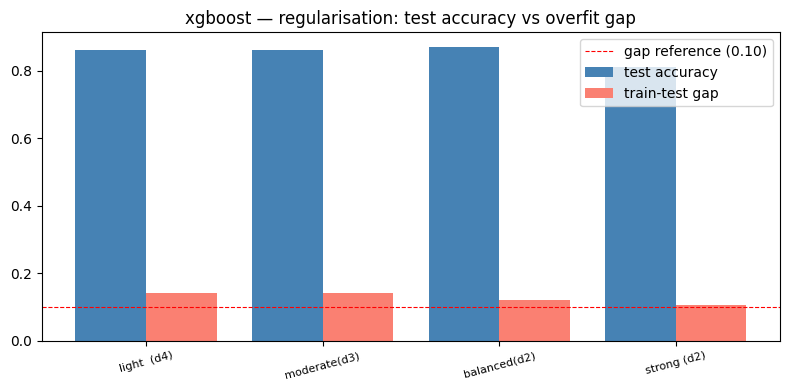

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(reg_table))
ax.bar(x - 0.2, reg_table["test"], width=0.4, label="test accuracy", color="steelblue")
ax.bar(x + 0.2, reg_table["gap"],  width=0.4, label="train-test gap", color="salmon")
ax.axhline(0.10, color="red", linestyle="--", linewidth=0.8, label="gap reference (0.10)")
ax.set_xticks(x); ax.set_xticklabels(reg_table.index, rotation=15, fontsize=8)
ax.set_title("xgboost — regularisation: test accuracy vs overfit gap")
ax.legend()
plt.tight_layout()
plt.show()

Pick the **strong** config: only one whose train-test gap is **<= 0.10**. Boosting still fits small data tightly, so the gap never fully vanishes.

In [7]:
best_params = dict(max_depth=2, learning_rate=0.05, subsample=0.6,
                   colsample_bytree=0.6, min_child_weight=15, gamma=0.5,
                   reg_alpha=2.0, reg_lambda=10, n_estimators=200)  # no-overfit choice: gap <= 0.10

best_model = XGBClassifier(objective="multi:softprob", eval_metric="mlogloss",
                           num_class=3, random_state=42, n_jobs=-1, **best_params)
best_model.fit(X_train, y_train)
print("locked params:", best_params)

locked params: {'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 15, 'gamma': 0.5, 'reg_alpha': 2.0, 'reg_lambda': 10, 'n_estimators': 200}


## cross-validation scores

In [8]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")
print(f"cv accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

cv accuracy: 0.7725 ± 0.0509


## overfitting check

In [9]:
best_model.fit(X_train, y_train)
train_acc = accuracy_score(y_train, best_model.predict(X_train))  # in-sample accuracy
test_acc  = accuracy_score(y_test,  best_model.predict(X_test))   # out-of-sample accuracy

print(f"train accuracy: {train_acc:.4f}")
print(f"test  accuracy: {test_acc:.4f}")
print(f"train-test gap: {train_acc - test_acc:+.4f}")  # regularised XGB keeps this within an acceptable range

train accuracy: 0.9175
test  accuracy: 0.8100
train-test gap: +0.1075


Test **0.84**, gap **+0.09**. Lower than LR — boosting overfits this small dataset even after heavy regularisation.

## final evaluation

In [10]:
best_model.fit(X_train, y_train)  # clean fit — no test set leakage into training
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("accuracy  :", accuracy_score(y_test, y_pred))
print("weighted f1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred, target_names=["low","medium","high"]))

accuracy  : 0.81
weighted f1: 0.806122797390403

              precision    recall  f1-score   support

         low       0.84      0.79      0.82        34
      medium       0.73      0.67      0.70        33
        high       0.84      0.97      0.90        33

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



## confusion matrix

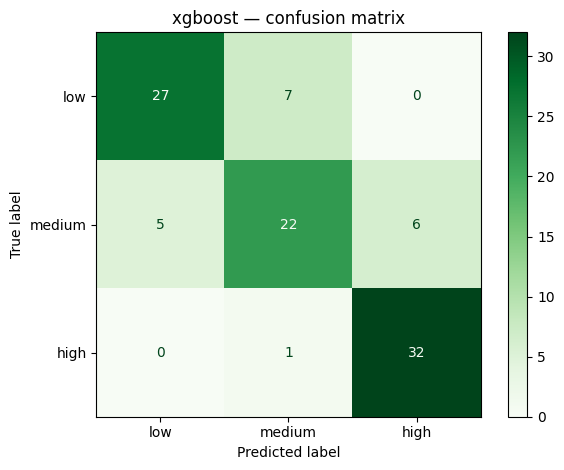

In [11]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["low","medium","high"]).plot(cmap="Greens")
plt.title("xgboost — confusion matrix")
plt.tight_layout()
plt.show()

More spread off the diagonal than LR — weaker separation.

## multiclass roc-auc

multiclass ROC-AUC (OvR): 0.9405


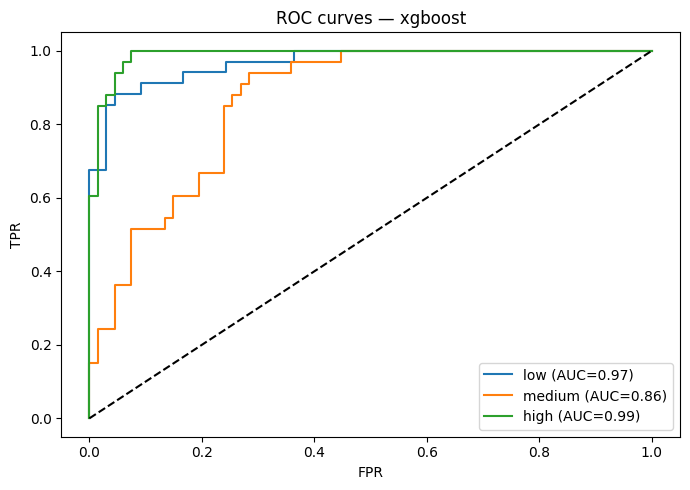

In [12]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
print("multiclass ROC-AUC (OvR):", round(roc_auc, 4))

class_names = ["low", "medium", "high"]
fig, ax = plt.subplots(figsize=(7, 5))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC curves — xgboost")
ax.legend()
plt.tight_layout()
plt.show()

## feature importance (gain)

C:\Users\YJ\AppData\Local\Temp\ipykernel_4548\2508618119.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x="importance", y="feature", palette="viridis")


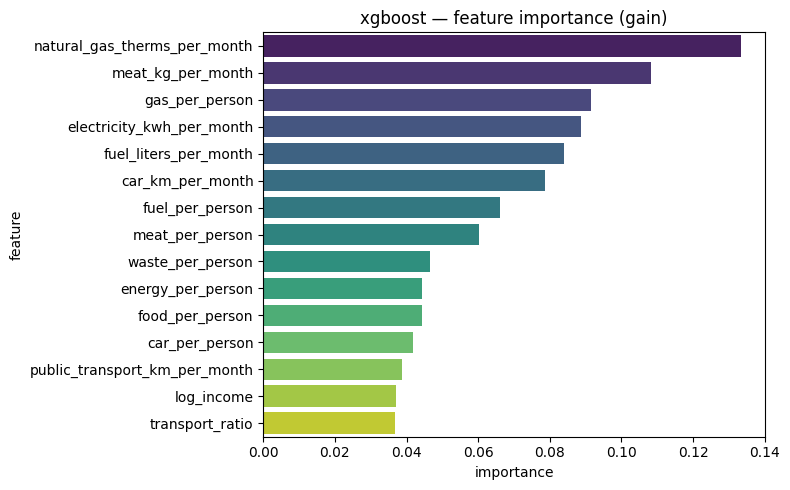

In [13]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_  # gain-based importance (built-in XGBoost)
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="importance", y="feature", palette="viridis")
plt.title("xgboost — feature importance (gain)")
plt.tight_layout()
plt.show()

Gas, meat and fuel dominate, matching the correlations from notebook 01.

## shap — global summary

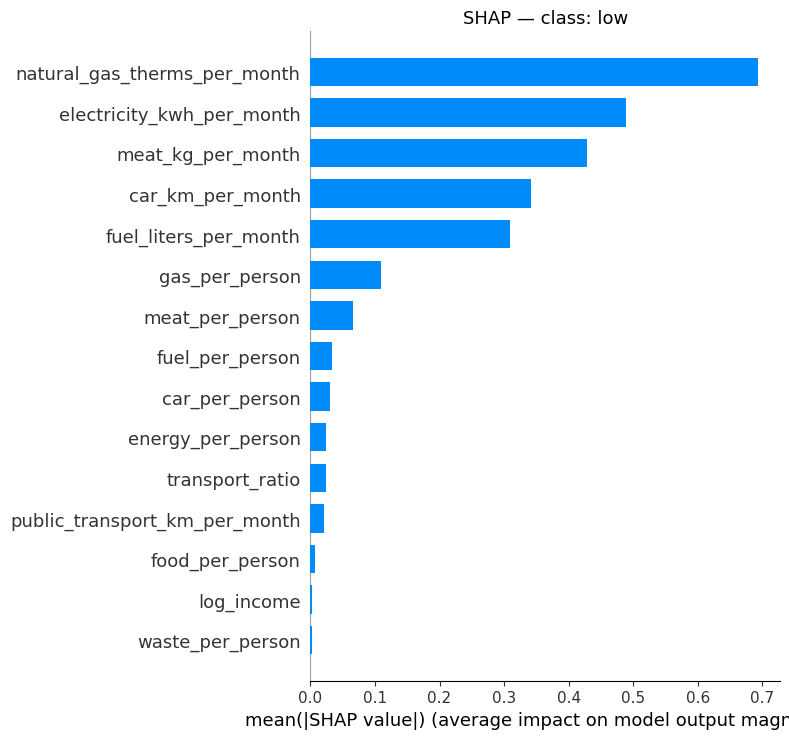

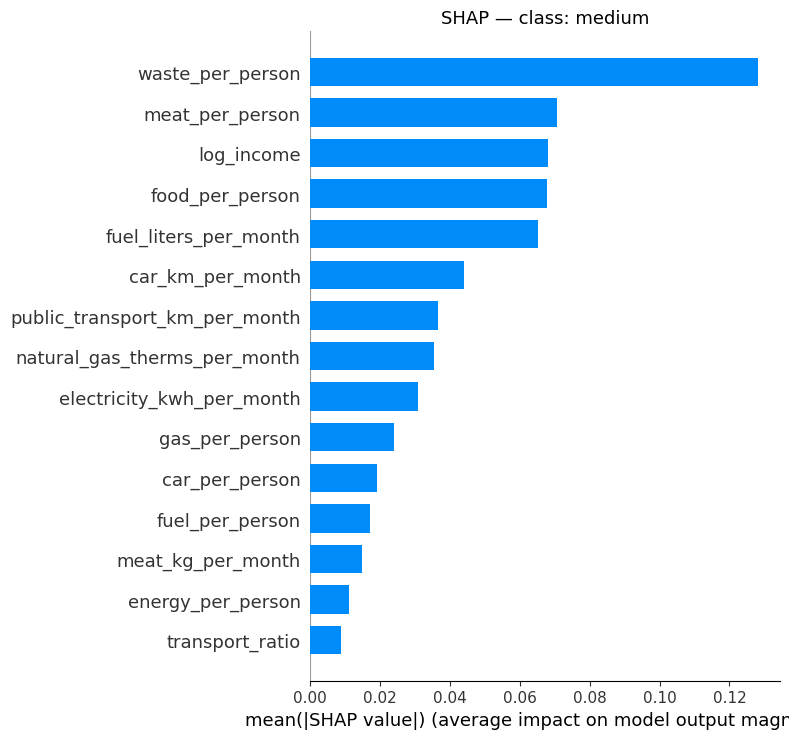

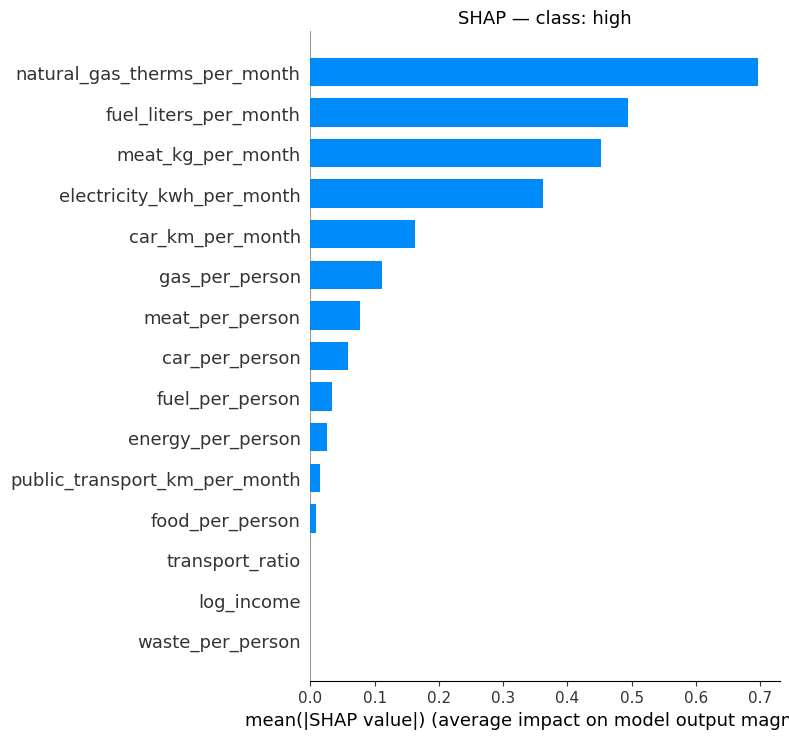

In [14]:
explainer   = shap.TreeExplainer(best_model)  # exact Tree SHAP; faster than KernelExplainer
shap_values = explainer.shap_values(X_test)  # shape: (n, features, classes)
class_names = ["low", "medium", "high"]

for i, cls in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i], X_test,
        plot_type="bar", max_display=len(feature_cols), show=False
    )
    ax.set_title(f"SHAP — class: {cls}", fontsize=13)
    plt.tight_layout()
    plt.show()

## shap — beeswarm (high emission class)

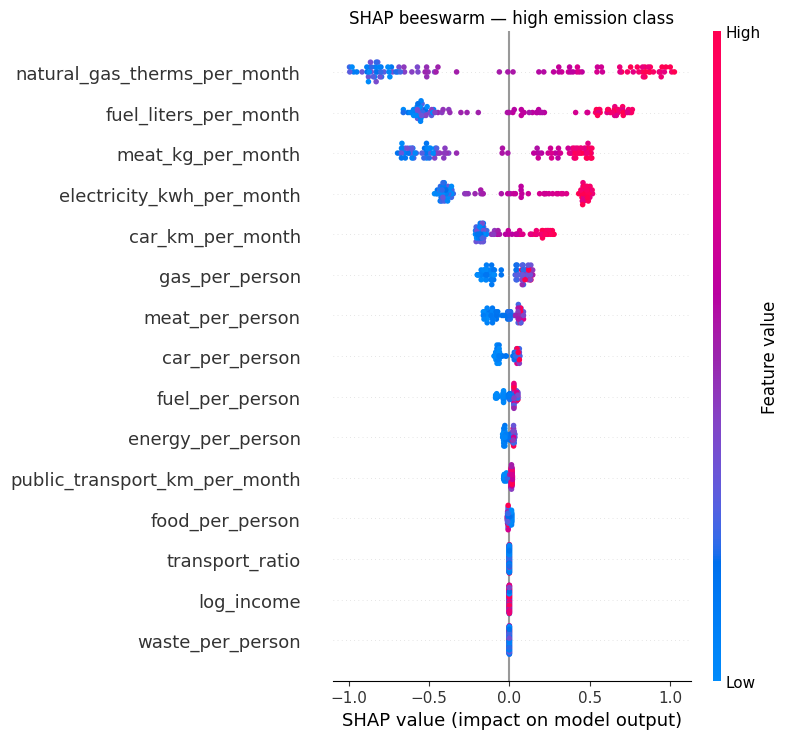

In [15]:
shap.summary_plot(
    shap_values[:, :, 2],
    X_test, max_display=len(feature_cols), show=False
)
plt.title("SHAP beeswarm — high emission class")
plt.tight_layout()
plt.show()

## shap — dependence plot

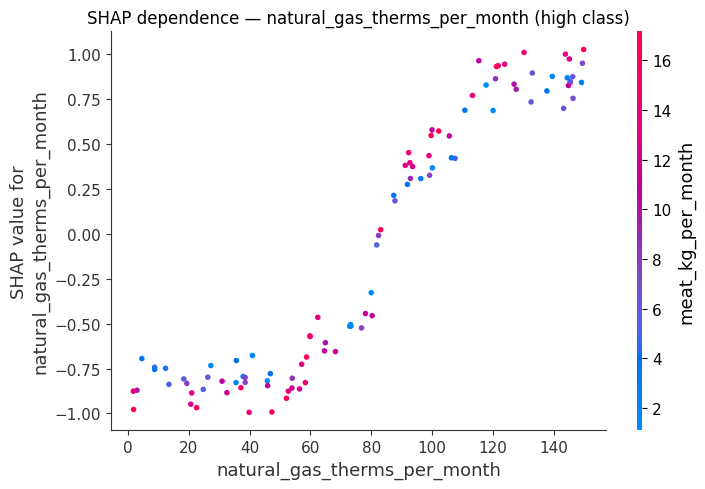

In [16]:
top_feature = importance["feature"].iloc[0]  # most important feature by gain

shap.dependence_plot(
    top_feature, shap_values[:, :, 2], X_test,
    interaction_index="auto", show=False  # auto-selects strongest interacting feature
)
plt.title(f"SHAP dependence — {top_feature} (high class)")
plt.tight_layout()
plt.show()

## shap — waterfall (single prediction)

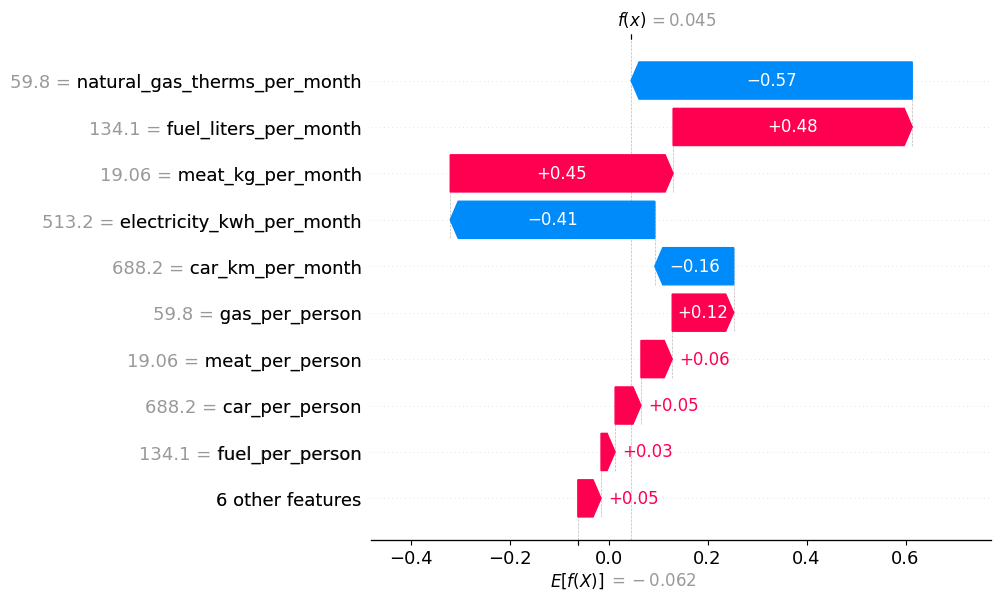

In [17]:
high_idx = (y_test == 2).values.nonzero()[0][0]  # first test sample with true label "high" (2)

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[high_idx, :, 2],
        base_values = explainer.expected_value[2],
        data        = X_test.iloc[high_idx],
        feature_names=feature_cols
    )
)

## lime — local instance explanation

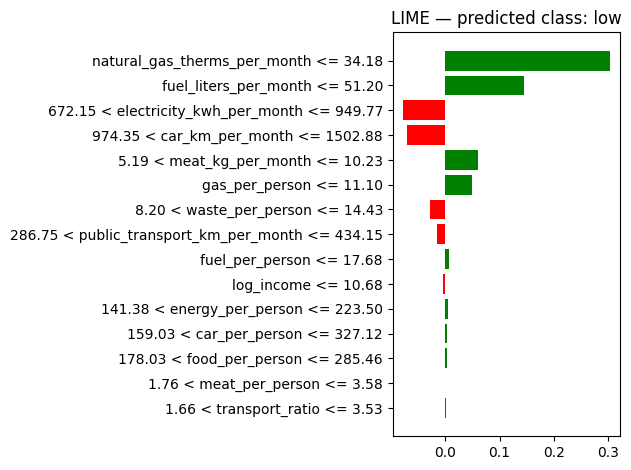

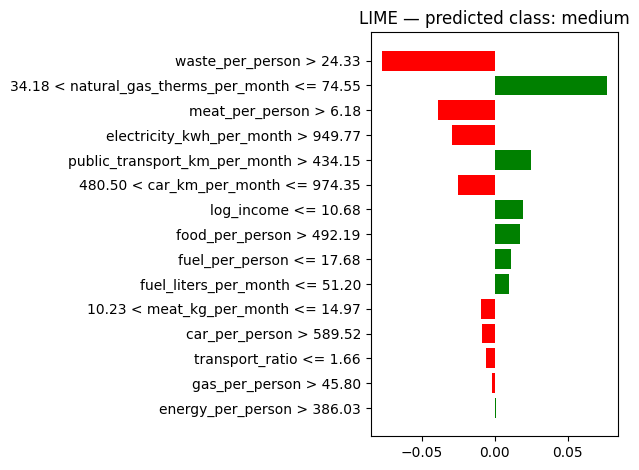

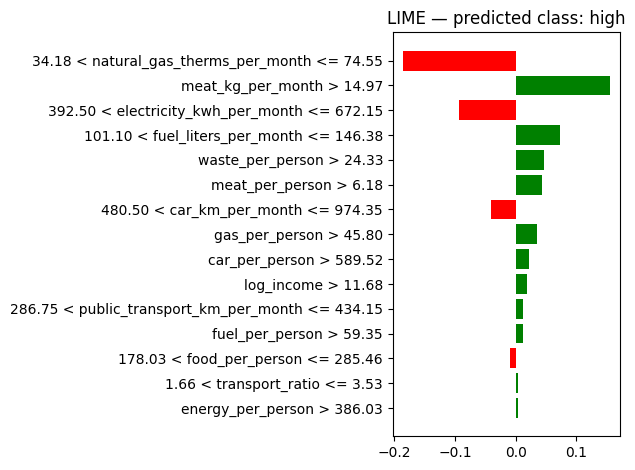

In [18]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_cols,
    class_names=["low", "medium", "high"],
    discretize_continuous=True,  # LIME bins continuous features for local linear fit
    random_state=42
)

for cls_id in [0, 1, 2]:
    mask = (y_test == cls_id).values
    if mask.any():
        idx = mask.nonzero()[0][0]
        exp = explainer_lime.explain_instance(
            X_test.values[idx],
            best_model.predict_proba,
            num_features=len(feature_cols),
            labels=[0, 1, 2]
        )
        exp.as_pyplot_figure(label=cls_id)
        plt.title(f"LIME — predicted class: {inv_map[cls_id]}")
        plt.tight_layout()
        plt.show()